<a href="https://colab.research.google.com/github/juvvalavinaysai/TO-DO-LIST-/blob/main/Copy_of_Covid19Proj10thSept.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##**Covid 19 Project**

Dataset link: https://drive.google.com/file/d/1TJdxCYLWOIDB4UPzXiLIOAfe1Sibmi6r/view?usp=sharing

**Import libraries**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

**Configurational library**

In [ ]:
import warnings
warnings.filterwarnings('ignore')

**Load Data**

In [ ]:
df = pd.read_csv('/content/covid_19_clean_complete.csv')

In [ ]:
df.head()

,Province/State,Country/Region,Lat,Long,Date,Confirmed,Deaths,Recovered,Active,WHO Region
0,NaN,Afghanistan,33.93911,67.709953,2020-01-22,0,0,0,0,Eastern Mediterranean
1,NaN,Albania,41.15330,20.168300,2020-01-22,0,0,0,0,Europe
2,NaN,Algeria,28.03390,1.659600,2020-01-22,0,0,0,0,Africa
3,NaN,Andorra,42.50630,1.521800,2020-01-22,0,0,0,0,Europe
4,NaN,Angola,-11.20270,17.873900,2020-01-22,0,0,0,0,Africa


**Shape analysis**

In [ ]:
df.shape

(49068, 10)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49068 entries, 0 to 49067
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Province/State  14664 non-null  object 
 1   Country/Region  49068 non-null  object 
 2   Lat             49068 non-null  float64
 3   Long            49068 non-null  float64
 4   Date            49068 non-null  object 
 5   Confirmed       49068 non-null  int64  
 6   Deaths          49068 non-null  int64  
 7   Recovered       49068 non-null  int64  
 8   Active          49068 non-null  int64  
 9   WHO Region      49068 non-null  object 
dtypes: float64(2), int64(4), object(4)
memory usage: 3.7+ MB


In [ ]:
df.isnull().sum()

,0
Province/State,34404
Country/Region,0
Lat,0
Long,0
Date,0
Confirmed,0
Deaths,0
Recovered,0
Active,0
WHO Region,0


In [ ]:
df.rename(columns ={'Province/State': 'State', 'Country/Region': 'Country'},inplace = True)

In [ ]:
df.head()

,State,Country,Lat,Long,Date,Confirmed,Deaths,Recovered,Active,WHO Region
0,NaN,Afghanistan,33.93911,67.709953,2020-01-22,0,0,0,0,Eastern Mediterranean
1,NaN,Albania,41.15330,20.168300,2020-01-22,0,0,0,0,Europe
2,NaN,Algeria,28.03390,1.659600,2020-01-22,0,0,0,0,Africa
3,NaN,Andorra,42.50630,1.521800,2020-01-22,0,0,0,0,Europe
4,NaN,Angola,-11.20270,17.873900,2020-01-22,0,0,0,0,Africa


In [ ]:
df.Date.value_counts()

,count
Date,
2020-01-22,261
2020-01-23,261
2020-01-24,261
2020-01-25,261
2020-01-26,261
...,...
2020-07-23,261
2020-07-24,261
2020-07-25,261


**We can see that max date will be 2020-07-27**

In [ ]:
df.Date.max()

'2020-07-27'

In [ ]:
df[df['Date'] == '2020-01-22']

,State,Country,Lat,Long,Date,Confirmed,Deaths,Recovered,Active,WHO Region
0,NaN,Afghanistan,33.939110,67.709953,2020-01-22,0,0,0,0,Eastern Mediterranean
1,NaN,Albania,41.153300,20.168300,2020-01-22,0,0,0,0,Europe
2,NaN,Algeria,28.033900,1.659600,2020-01-22,0,0,0,0,Africa
3,NaN,Andorra,42.506300,1.521800,2020-01-22,0,0,0,0,Europe
4,NaN,Angola,-11.202700,17.873900,2020-01-22,0,0,0,0,Africa
...,...,...,...,...,...,...,...,...,...,...
256,NaN,Sao Tome and Principe,0.186400,6.613100,2020-01-22,0,0,0,0,Africa
257,NaN,Yemen,15.552727,48.516388,2020-01-22,0,0,0,0,Eastern Mediterranean
258,NaN,Comoros,-11.645500,43.333300,2020-01-22,0,0,0,0,Africa
259,NaN,Tajikistan,38.861000,71.276100,2020-01-22,0,0,0,0,Europe


**Population rows with max data in top**

In [ ]:
top = df[df['Date'] == '2020-07-27']
top.head()

,State,Country,Lat,Long,Date,Confirmed,Deaths,Recovered,Active,WHO Region
48807,NaN,Afghanistan,33.93911,67.709953,2020-07-27,36263,1269,25198,9796,Eastern Mediterranean
48808,NaN,Albania,41.15330,20.168300,2020-07-27,4880,144,2745,1991,Europe
48809,NaN,Algeria,28.03390,1.659600,2020-07-27,27973,1163,18837,7973,Africa
48810,NaN,Andorra,42.50630,1.521800,2020-07-27,907,52,803,52,Europe
48811,NaN,Angola,-11.20270,17.873900,2020-07-27,950,41,242,667,Africa


**Grouing all rows based on country**

In [ ]:
top.groupby(by='Country')[['Confirmed',	'Deaths', 'Recovered',	'Active']].sum().reset_index()

,Country,Confirmed,Deaths,Recovered,Active
0,Afghanistan,36263,1269,25198,9796
1,Albania,4880,144,2745,1991
2,Algeria,27973,1163,18837,7973
3,Andorra,907,52,803,52
4,Angola,950,41,242,667
...,...,...,...,...,...
182,West Bank and Gaza,10621,78,3752,6791
183,Western Sahara,10,1,8,1
184,Yemen,1691,483,833,375
185,Zambia,4552,140,2815,1597


**Let's Talk more about Confirmed cases**

In [ ]:
confirmed = df.groupby(by='Date')['Confirmed'].sum().reset_index()

In [ ]:
confirmed.head()

,Date,Confirmed
0,2020-01-22,555
1,2020-01-23,654
2,2020-01-24,941
3,2020-01-25,1434
4,2020-01-26,2118


In [ ]:
confirmed.tail()

,Date,Confirmed
183,2020-07-23,15510481
184,2020-07-24,15791645
185,2020-07-25,16047190
186,2020-07-26,16251796
187,2020-07-27,16480485


In [ ]:
df.Date.unique()

array(['2020-01-22', '2020-01-23', '2020-01-24', '2020-01-25',
       '2020-01-26', '2020-01-27', '2020-01-28', '2020-01-29',
       '2020-01-30', '2020-01-31', '2020-02-01', '2020-02-02',
       '2020-02-03', '2020-02-04', '2020-02-05', '2020-02-06',
       '2020-02-07', '2020-02-08', '2020-02-09', '2020-02-10',
       '2020-02-11', '2020-02-12', '2020-02-13', '2020-02-14',
       '2020-02-15', '2020-02-16', '2020-02-17', '2020-02-18',
       '2020-02-19', '2020-02-20', '2020-02-21', '2020-02-22',
       '2020-02-23', '2020-02-24', '2020-02-25', '2020-02-26',
       '2020-02-27', '2020-02-28', '2020-02-29', '2020-03-01',
       '2020-03-02', '2020-03-03', '2020-03-04', '2020-03-05',
       '2020-03-06', '2020-03-07', '2020-03-08', '2020-03-09',
       '2020-03-10', '2020-03-11', '2020-03-12', '2020-03-13',
       '2020-03-14', '2020-03-15', '2020-03-16', '2020-03-17',
       '2020-03-18', '2020-03-19', '2020-03-20', '2020-03-21',
       '2020-03-22', '2020-03-23', '2020-03-24', '2020-

**Find the same for death, Active and recovered case**

**Let's Plot the graph to see how confirmed cases got increase**

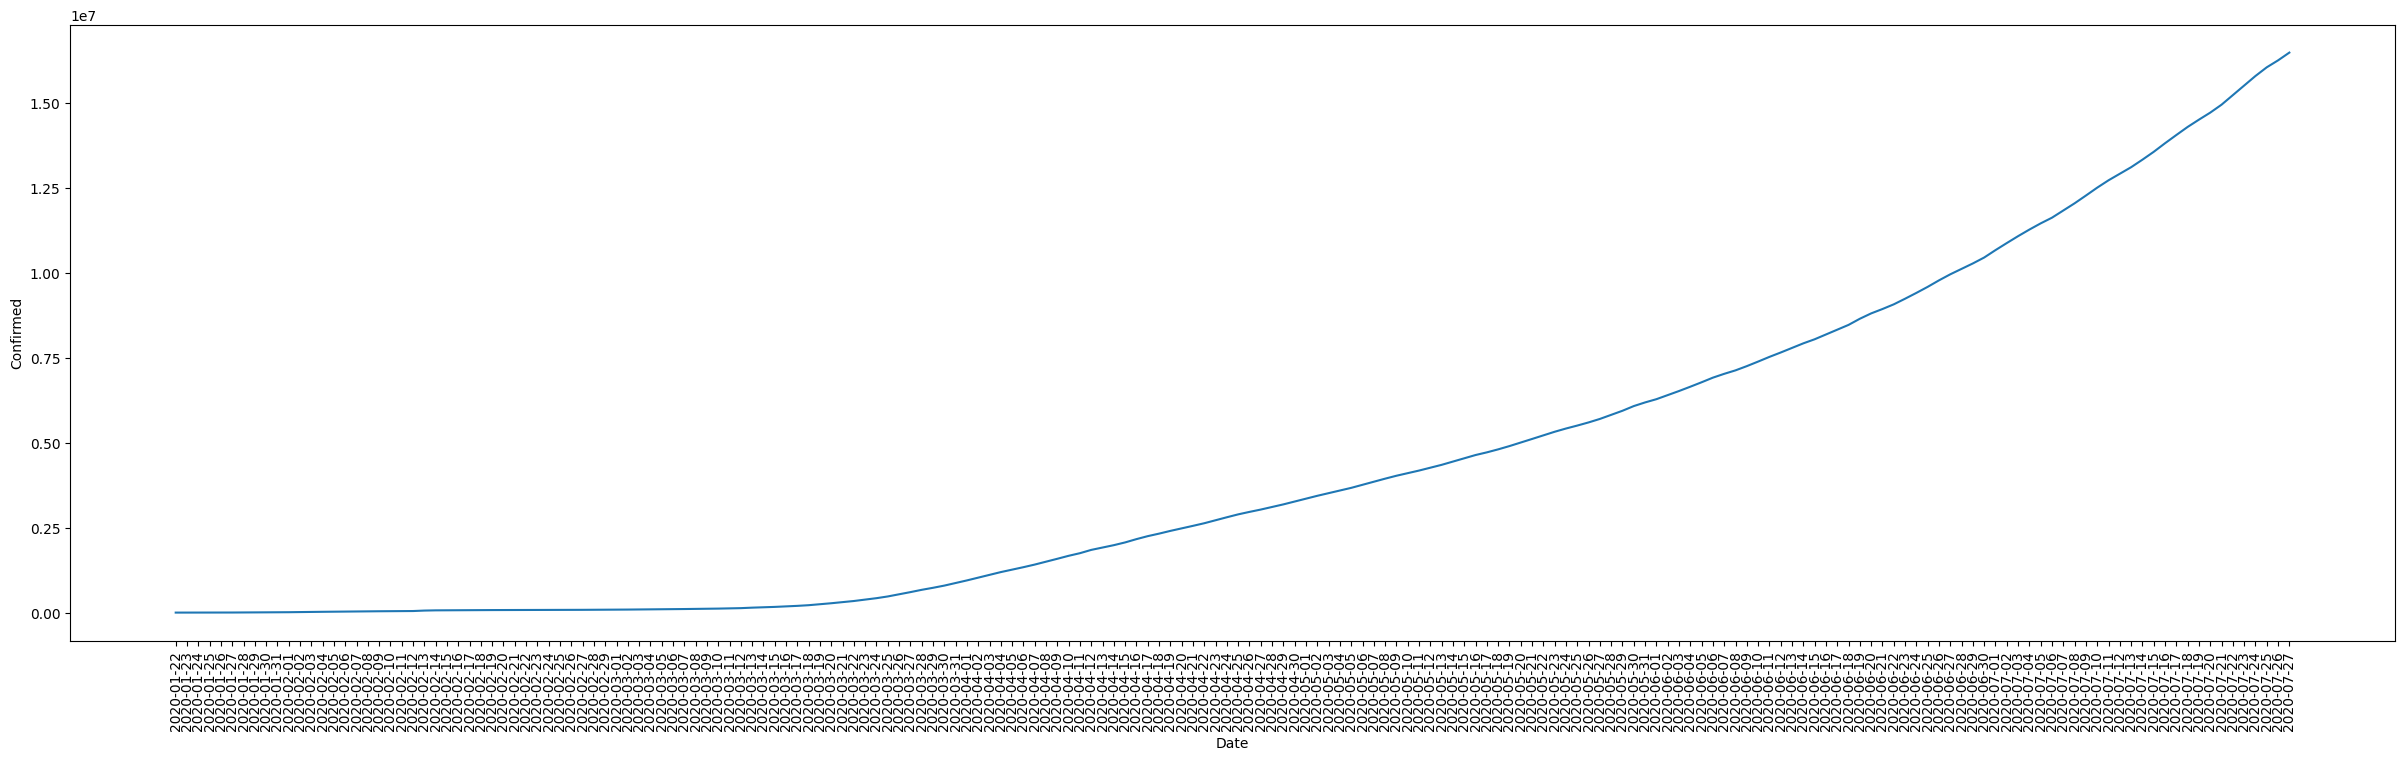

In [ ]:
plt.figure(figsize = (30,8))
sns.lineplot(data = confirmed, x = 'Date', y='Confirmed')
plt.xticks(rotation = 90)
plt.show()

**Top 10 Countries with the most recovered cases**

In [ ]:
top_10_recovered = df.groupby(by='Country')['Recovered'].sum()

In [ ]:
top_10_recovered.sort_values(ascending=False, inplace= True)

In [ ]:
top_10_recovered.head(10)

,Recovered
Country,
US,56353416
Brazil,54492873
Russia,25120448
India,23783720
Germany,17107839
Italy,15673910
Iran,15200895
Spain,15093583
Turkey,13345389


**Find for Death, Confirmed and Active cases too**

**Let's Do for the active cases**

In [ ]:
top_10_active = df.groupby(by='Country')['Active'].sum().sort_values(ascending=False).head(10).reset_index()
# Method chaining

In [ ]:
top_10_active

,Country,Active
0,US,156981121
1,Brazil,31094060
2,United Kingdom,22624595
3,Russia,19668578
4,India,15987913
5,France,10980287
6,Spain,9277432
7,Canada,8656985
8,Peru,7748957
9,Italy,7363518


**Let's Create the dataset specific for US**

In [ ]:
US = df[df['Country'] == 'US']
US.tail()

,State,Country,Lat,Long,Date,Confirmed,Deaths,Recovered,Active,WHO Region
47986,NaN,US,40.0,-100.0,2020-07-23,4038816,144430,1233269,2661117,Americas
48247,NaN,US,40.0,-100.0,2020-07-24,4112531,145560,1261624,2705347,Americas
48508,NaN,US,40.0,-100.0,2020-07-25,4178970,146465,1279414,2753091,Americas
48769,NaN,US,40.0,-100.0,2020-07-26,4233923,146935,1297863,2789125,Americas
49030,NaN,US,40.0,-100.0,2020-07-27,4290259,148011,1325804,2816444,Americas


In [ ]:
India = df[df['Country'] == 'India']
India.head()

,State,Country,Lat,Long,Date,Confirmed,Deaths,Recovered,Active,WHO Region
129,NaN,India,20.593684,78.96288,2020-01-22,0,0,0,0,South-East Asia
390,NaN,India,20.593684,78.96288,2020-01-23,0,0,0,0,South-East Asia
651,NaN,India,20.593684,78.96288,2020-01-24,0,0,0,0,South-East Asia
912,NaN,India,20.593684,78.96288,2020-01-25,0,0,0,0,South-East Asia
1173,NaN,India,20.593684,78.96288,2020-01-26,0,0,0,0,South-East Asia


In [ ]:
China = df[df['Country'] == 'China']
China.tail()

,State,Country,Lat,Long,Date,Confirmed,Deaths,Recovered,Active,WHO Region
48883,Tianjin,China,39.3054,117.3230,2020-07-27,204,3,195,6,Western Pacific
48884,Tibet,China,31.6927,88.0924,2020-07-27,1,0,1,0,Western Pacific
48885,Xinjiang,China,41.1129,85.2401,2020-07-27,311,3,73,235,Western Pacific
48886,Yunnan,China,24.9740,101.4870,2020-07-27,190,2,186,2,Western Pacific
48887,Zhejiang,China,29.1832,120.0934,2020-07-27,1270,1,1268,1,Western Pacific


**HW: Calculate these cases for 3-4 more countries then compare the graph of those countries to check how the cases were changed**

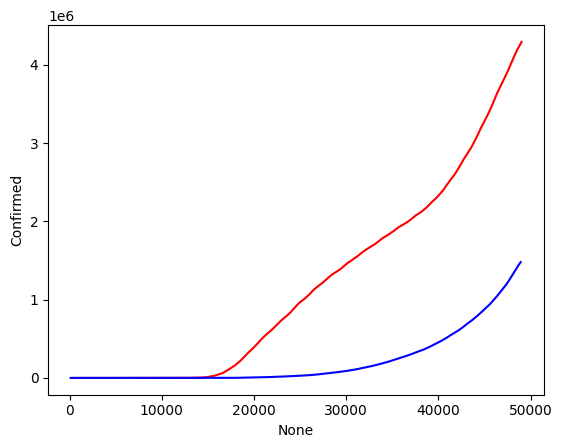

In [ ]:
sns.lineplot(data=US,x=US.index, y=US.Confirmed, color = 'Red')
sns.lineplot(data=India,x=India.index, y=India.Confirmed, color = 'Blue')
plt.show()

###**Model Build (Prophet)**
**Note: Prophet is a Time Series model used for Forecasting**
* It is developed by Facebook in 2017 (now META)

In [ ]:
!pip install prophet

In [ ]:
df1 = pd.read_csv('/content/covid_19_clean_complete.csv')

**Now i will create data specifically for Confirmed cases**

In [ ]:
confirmed = df1.groupby(by = 'Date')['Confirmed'].sum().reset_index()

In [ ]:
confirmed

,Date,Confirmed
0,2020-01-22,555
1,2020-01-23,654
2,2020-01-24,941
3,2020-01-25,1434
4,2020-01-26,2118
...,...,...
183,2020-07-23,15510481
184,2020-07-24,15791645
185,2020-07-25,16047190
186,2020-07-26,16251796


**I will Forecast for confirmed cases**
* you guys need to do the forecasting for death, recover and active

###**Forecast**
* Make sure to rename the date column as 'ds' and target column as 'y'

In [ ]:
confirmed.columns = ['ds','y']
confirmed.head()

,ds,y
0,2020-01-22,555
1,2020-01-23,654
2,2020-01-24,941
3,2020-01-25,1434
4,2020-01-26,2118


In [ ]:
from prophet import Prophet
m = Prophet()

In [ ]:
m.fit(confirmed)

INFO:prophet:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
DEBUG:cmdstanpy:input tempfile: /tmp/tmppnmow06_/bv6c4d9_.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmppnmow06_/4oqtcf8z.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.12/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=32331', 'data', 'file=/tmp/tmppnmow06_/bv6c4d9_.json', 'init=/tmp/tmppnmow06_/4oqtcf8z.json', 'output', 'file=/tmp/tmppnmow06_/prophet_modeljsymmzp6/prophet_model-20251024152555.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
15:25:55 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
15:25:55 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


**Making Prediction for next 7 month**

In [ ]:
# Keyword alert: method name: make_future_dataframe()
future = m.make_future_dataframe(periods=7)
forecast = m.predict(future)
forecast

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,weekly,weekly_lower,weekly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,2020-01-22,-9.613281e+03,-1.253132e+05,8.262704e+04,-9.613281e+03,-9.613281e+03,-11063.561776,-11063.561776,-11063.561776,-11063.561776,-11063.561776,-11063.561776,0.0,0.0,0.0,-2.067684e+04
1,2020-01-23,-6.933404e+03,-1.090131e+05,9.702103e+04,-6.933404e+03,-6.933404e+03,-1117.543336,-1117.543336,-1117.543336,-1117.543336,-1117.543336,-1117.543336,0.0,0.0,0.0,-8.050948e+03
2,2020-01-24,-4.253528e+03,-1.079189e+05,1.087569e+05,-4.253528e+03,-4.253528e+03,10080.982351,10080.982351,10080.982351,10080.982351,10080.982351,10080.982351,0.0,0.0,0.0,5.827455e+03
3,2020-01-25,-1.573651e+03,-8.475816e+04,1.203157e+05,-1.573651e+03,-1.573651e+03,13750.330594,13750.330594,13750.330594,13750.330594,13750.330594,13750.330594,0.0,0.0,0.0,1.217668e+04
4,2020-01-26,1.106226e+03,-9.927354e+04,1.134649e+05,1.106226e+03,1.106226e+03,7298.794381,7298.794381,7298.794381,7298.794381,7298.794381,7298.794381,0.0,0.0,0.0,8.405020e+03
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
190,2020-07-30,1.674503e+07,1.664187e+07,1.685783e+07,1.673887e+07,1.675058e+07,-1117.543336,-1117.543336,-1117.543336,-1117.543336,-1117.543336,-1117.543336,0.0,0.0,0.0,1.674391e+07
191,2020-07-31,1.694902e+07,1.684384e+07,1.706278e+07,1.693777e+07,1.696052e+07,10080.982351,10080.982351,10080.982351,10080.982351,10080.982351,10080.982351,0.0,0.0,0.0,1.695910e+07
192,2020-08-01,1.715301e+07,1.706014e+07,1.727841e+07,1.713412e+07,1.717360e+07,13750.330594,13750.330594,13750.330594,13750.330594,13750.330594,13750.330594,0.0,0.0,0.0,1.716676e+07
193,2020-08-02,1.735700e+07,1.725216e+07,1.747788e+07,1.732952e+07,1.738694e+07,7298.794381,7298.794381,7298.794381,7298.794381,7298.794381,7298.794381,0.0,0.0,0.0,1.736430e+07


In [ ]:
forecast[['ds','yhat','yhat_lower',	'yhat_upper']]

,ds,yhat,yhat_lower,yhat_upper
0,2020-01-22,-2.067684e+04,-1.253132e+05,8.262704e+04
1,2020-01-23,-8.050948e+03,-1.090131e+05,9.702103e+04
2,2020-01-24,5.827455e+03,-1.079189e+05,1.087569e+05
3,2020-01-25,1.217668e+04,-8.475816e+04,1.203157e+05
4,2020-01-26,8.405020e+03,-9.927354e+04,1.134649e+05
...,...,...,...,...
190,2020-07-30,1.674391e+07,1.664187e+07,1.685783e+07
191,2020-07-31,1.695910e+07,1.684384e+07,1.706278e+07
192,2020-08-01,1.716676e+07,1.706014e+07,1.727841e+07
193,2020-08-02,1.736430e+07,1.725216e+07,1.747788e+07


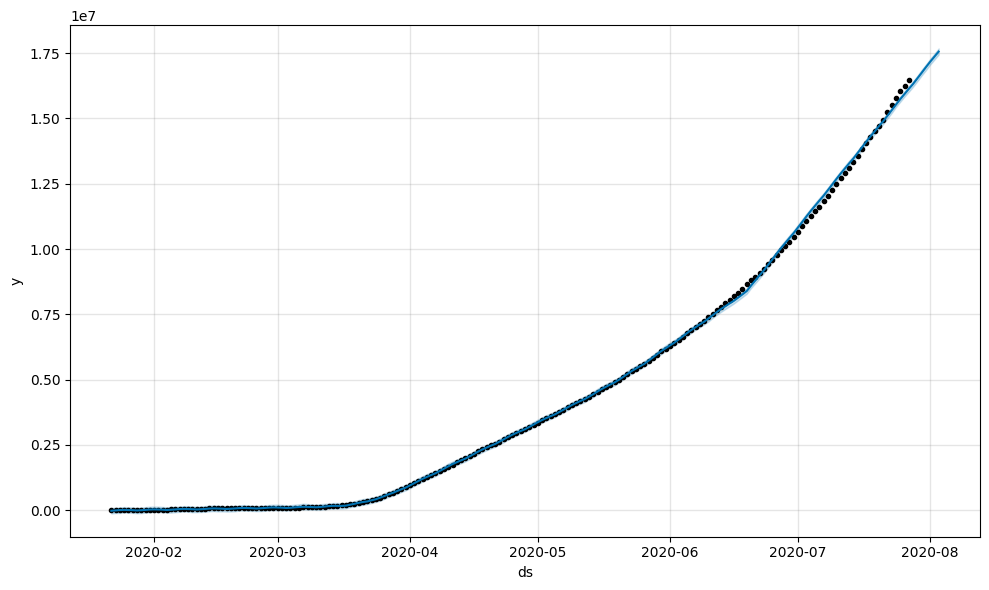

In [ ]:
m.plot(forecast)
plt.show()

**Choropleth graph**

In [ ]:
import plotly
import plotly.express as px

In [ ]:
df1.columns

Index(['Province/State', 'Country/Region', 'Lat', 'Long', 'Date', 'Confirmed',
       'Deaths', 'Recovered', 'Active', 'WHO Region'],
      dtype='object')

In [ ]:
world = df1.groupby(by='Country/Region')[['Confirmed',
       'Deaths', 'Recovered', 'Active']].sum().reset_index()

In [ ]:
world

,Country/Region,Confirmed,Deaths,Recovered,Active
0,Afghanistan,1936390,49098,798240,1089052
1,Albania,196702,5708,118877,72117
2,Algeria,1179755,77972,755897,345886
3,Andorra,94404,5423,69074,19907
4,Angola,22662,1078,6573,15011
...,...,...,...,...,...
182,West Bank and Gaza,233461,1370,61124,170967
183,Western Sahara,901,63,648,190
184,Yemen,67180,17707,23779,25694
185,Zambia,129421,2643,83611,43167


In [ ]:
fig = px.choropleth(world,locations = 'Country/Region',
                    locationmode= 'country names',
                    color = 'Active',hover_name = 'Country/Region',
                    color_continuous_scale='blues',
                    title='Countries with Active cases')
fig.show()

In [ ]:
df['Date'] = pd.to_datetime(df['Date'])
df.info() # Verify the Dtype change

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49068 entries, 0 to 49067
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   State       14664 non-null  object        
 1   Country     49068 non-null  object        
 2   Lat         49068 non-null  float64       
 3   Long        49068 non-null  float64       
 4   Date        49068 non-null  datetime64[ns]
 5   Confirmed   49068 non-null  int64         
 6   Deaths      49068 non-null  int64         
 7   Recovered   49068 non-null  int64         
 8   Active      49068 non-null  int64         
 9   WHO Region  49068 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(4), object(3)
memory usage: 3.7+ MB


              WHO Region  Confirmed  Deaths  Recovered   Active
0                 Africa     723207   12223     440645   270339
1               Americas    8839286  342732    4468616  4027938
2  Eastern Mediterranean    1490744   38339    1201400   251005
3                 Europe    3299523  211144    1993723  1094656
4        South-East Asia    1835297   41349    1156933   637015
5        Western Pacific     292428    8249     206770    77409


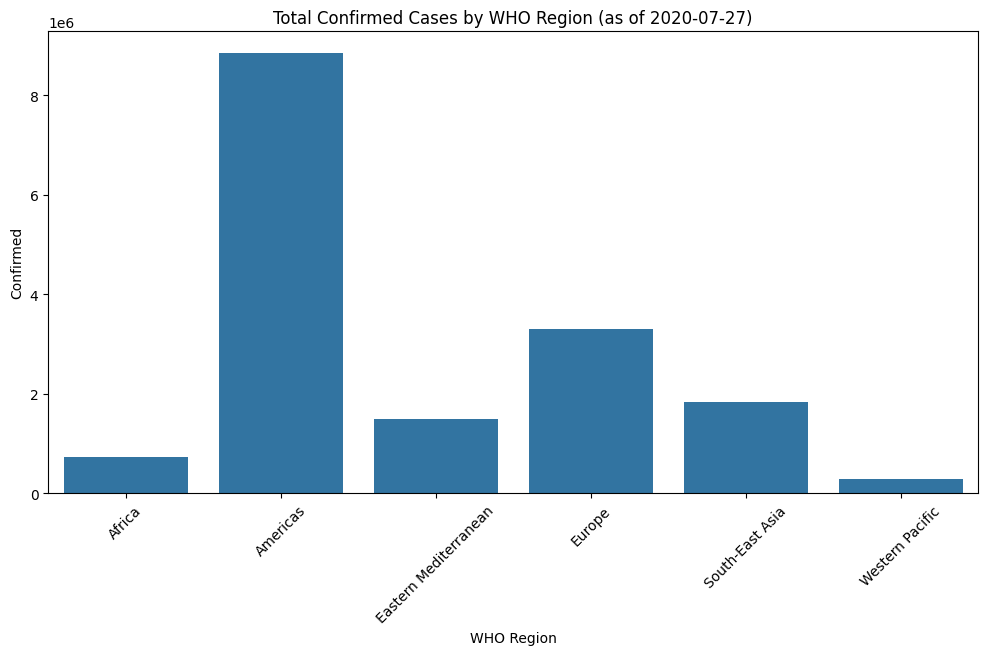

In [ ]:
# Use the 'top' dataframe (filtered for the latest date: 2020-07-27)
region_cases = top.groupby('WHO Region')[['Confirmed', 'Deaths', 'Recovered', 'Active']].sum().reset_index()
print(region_cases)

# Visualize regional distribution (e.g., bar chart)
plt.figure(figsize=(12, 6))
sns.barplot(data=region_cases, x='WHO Region', y='Confirmed')
plt.title('Total Confirmed Cases by WHO Region (as of 2020-07-27)')
plt.xticks(rotation=45)
plt.show()

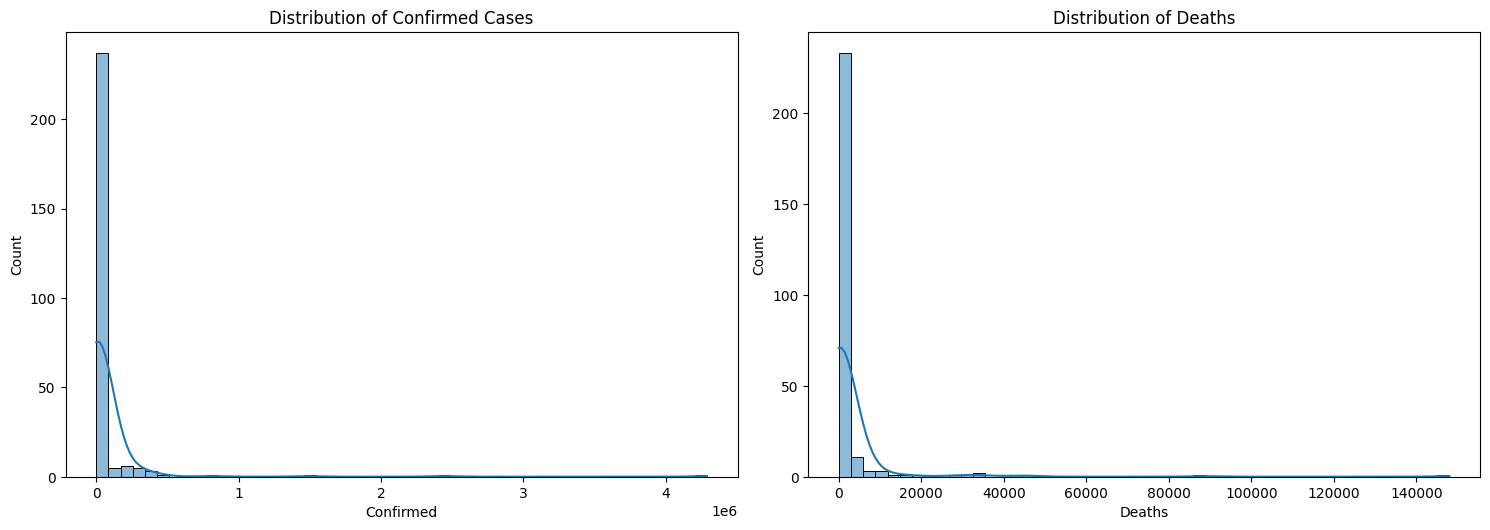

In [ ]:
plt.figure(figsize=(15, 10))
plt.subplot(2, 2, 1)
sns.histplot(top['Confirmed'], bins=50, kde=True)
plt.title('Distribution of Confirmed Cases')

plt.subplot(2, 2, 2)
sns.histplot(top['Deaths'], bins=50, kde=True)
plt.title('Distribution of Deaths')
# ... Add plots for Recovered and Active ...
plt.tight_layout()
plt.show()

In [ ]:
world_latest = top.groupby('Country')[['Confirmed', 'Deaths', 'Recovered']].sum().reset_index()
world_latest['Mortality Rate (%)'] = (world_latest['Deaths'] / world_latest['Confirmed']) * 100
world_latest['Recovery Rate (%)'] = (world_latest['Recovered'] / world_latest['Confirmed']) * 100
world_latest.fillna(0, inplace=True) # Handle division by zero -> NaN

print(world_latest.sort_values(by='Mortality Rate (%)', ascending=False).head(10))
print(world_latest.sort_values(by='Recovery Rate (%)', ascending=False).head(10))

            Country  Confirmed  Deaths  Recovered  Mortality Rate (%)  \
184           Yemen       1691     483        833           28.562980   
177  United Kingdom     301708   45844       1437           15.194824   
16          Belgium      66428    9822      17452           14.785934   
85            Italy     246286   35112     198593           14.256596   
61           France     220352   30212      81212           13.710790   
77          Hungary       4448     596       3329           13.399281   
120     Netherlands      53413    6160        189           11.532773   
111          Mexico     395489   44022     303810           11.131030   
157           Spain     272421   28432     150376           10.436787   
183  Western Sahara         10       1          8           10.000000   

     Recovery Rate (%)  
184          49.260792  
177           0.476288  
16           26.272054  
85           80.635115  
61           36.855577  
77           74.842626  
120           0.35384

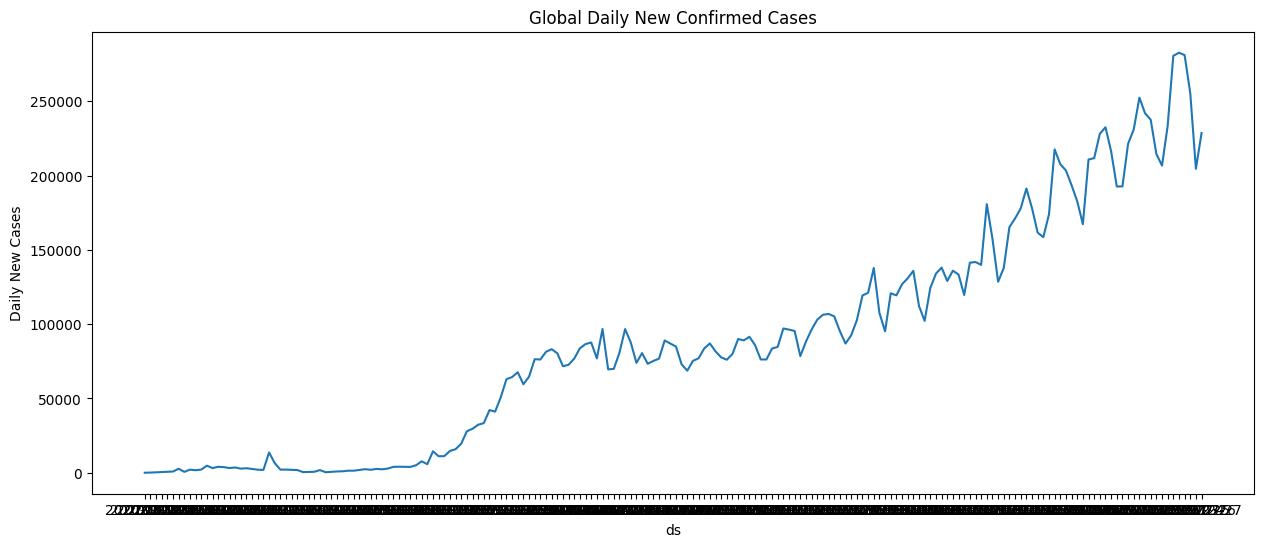

In [ ]:
# Use the 'confirmed' dataframe created earlier
confirmed['Daily New Cases'] = confirmed['y'].diff().fillna(0)
confirmed.head()

# Visualize daily new cases
plt.figure(figsize=(15, 6))
sns.lineplot(data=confirmed, x='ds', y='Daily New Cases')
plt.title('Global Daily New Confirmed Cases')
plt.show()

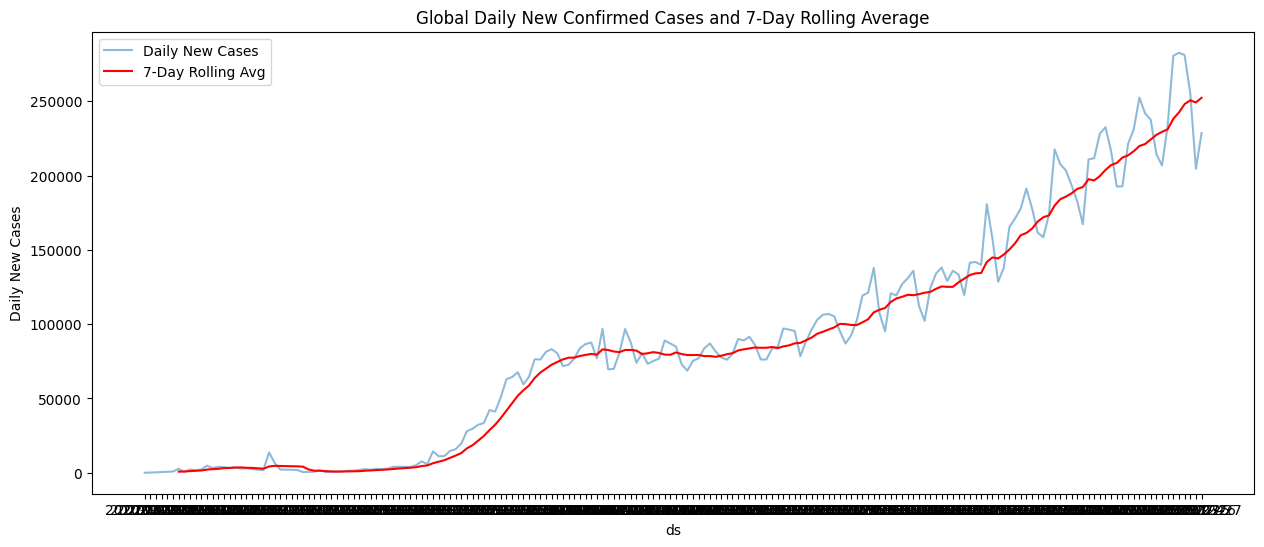

In [ ]:
confirmed['7-Day Rolling Avg'] = confirmed['Daily New Cases'].rolling(window=7).mean()

# Visualize daily cases and rolling average
plt.figure(figsize=(15, 6))
sns.lineplot(data=confirmed, x='ds', y='Daily New Cases', label='Daily New Cases', alpha=0.5)
sns.lineplot(data=confirmed, x='ds', y='7-Day Rolling Avg', label='7-Day Rolling Avg', color='red')
plt.title('Global Daily New Confirmed Cases and 7-Day Rolling Average')
plt.legend()
plt.show()

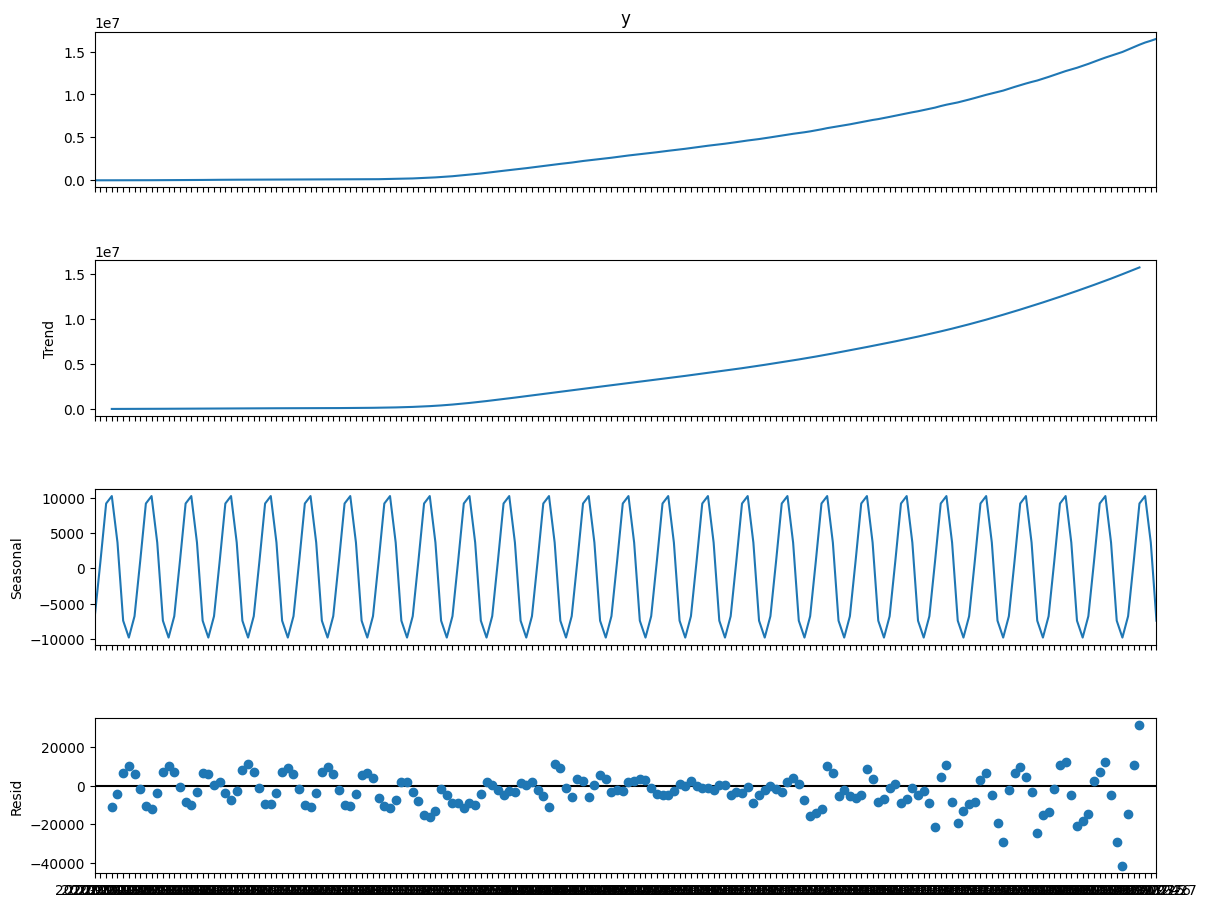

In [ ]:
from statsmodels.tsa.seasonal import seasonal_decompose
import matplotlib.pyplot as plt

# Set 'ds' as index for decomposition
confirmed_indexed = confirmed.set_index('ds')

# Perform decomposition (assuming weekly seasonality, period=7)
decomposition = seasonal_decompose(confirmed_indexed['y'], model='additive', period=7)

# Plot the components
fig = decomposition.plot()
fig.set_size_inches(14, 10)
plt.show()

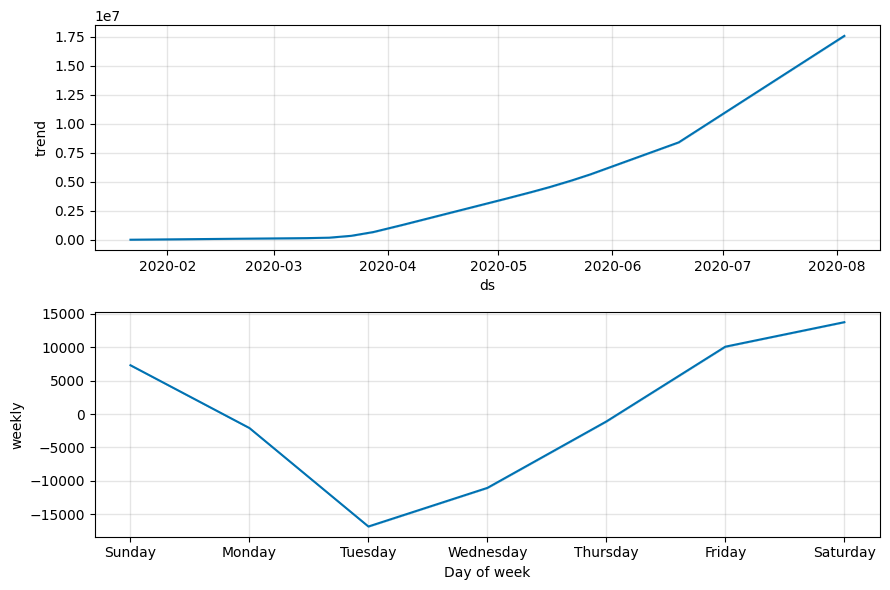

In [ ]:
fig_components = m.plot_components(forecast)
plt.show()